### Import

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [21]:
df = pd.read_csv("../data/processed/rossmannV2.csv")

### Correlation

In [22]:
corr_with_target = (
    df.corr(method='spearman')["Sales"].drop('Sales')
)

Since all columns are numerical I'm gonna use correlation on all features.

I used spearman method because I wanna know does each feature tend to decrease or increase with Sales instead of linear correlation.

---

In [23]:
top_positive = corr_with_target.sort_values(ascending=False).head(10)
top_negative = corr_with_target.sort_values().head(10)

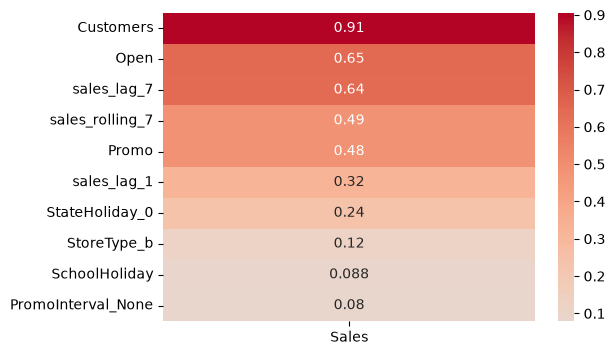

In [24]:
heatmap_data_pos = top_positive.to_frame(name="Sales")

plt.figure(figsize=(6, 4))
sns.heatmap(heatmap_data_pos, annot=True, center=0, cmap='coolwarm')

plt.show()

Based on top positive correlation heatmap I found out that Sales tend to increase if:
- There're `many customers`

- Store is `open`

And that's pretty obvious but there're also 3 insightful examples. Sales will increase if :
- Store is on `Promo`, which shows that promo works 

- If there's `no holiday` or it's a school holiday (students tend to go to store)

- And if `store type is B` (there's no certain information about it's exact meaning)

---

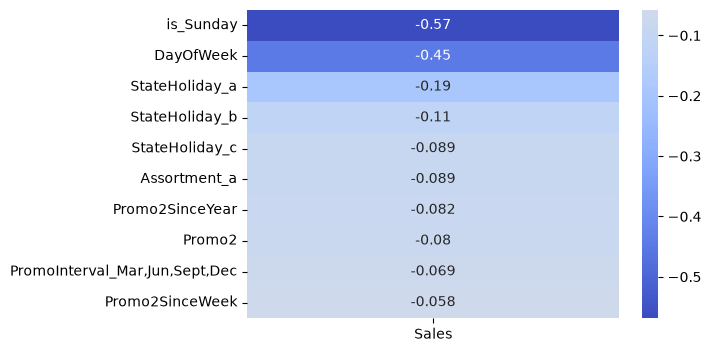

In [28]:
heatmap_data_neg = top_negative.to_frame(name="Sales")

plt.figure(figsize=(6, 4))
sns.heatmap(heatmap_data_neg, annot=True, center=0, cmap='coolwarm')

plt.show()

Based on top negative correlation heatmap I found out that Sales tend to decrease if:
- It's `Sunday` and `Day of week is High` which is easily explained by EU system -> Stores are closed on Sundays.

- Also if `there's a holiday` (especially A and B types which are `Public holiday and Easter`) and it's reasonable since Stores are also closed during those days.

- If assortment is type A -> Basic

- If store is participating in a `Second promotion` especially if it's runs during `March to December period`

---

### VIF

In [53]:
categorical_cols = [
    'PromoInterval_Mar,Jun,Sept,Dec',
    'PromoInterval_Jan,Apr,Jul,Oct',
    'PromoInterval_None',
    'Promo2',
    'StoreType_d',
    'StoreType_c',
    'StoreType_a',
    'StoreType_b',
    'Assortment_c',
    'Assortment_b',
    'Assortment_a',
    'PromoInterval_Feb,May,Aug,Nov',
    'StateHoliday_c',
    'StateHoliday_b',
    'StateHoliday_a',
    'StateHoliday_0'
]

numeric_cols = [
    col for col in df.select_dtypes("number").columns
    if col not in categorical_cols + ["Sales", "Store"]
]

Categorical features will return inf value in VIF so we have to seperate them from numerical columns

In [57]:
X = df[numeric_cols].dropna()

X_sample = X.sample(
    n=min(500_000, len(X)),
    random_state=42
)

Dataset is 1 million rows which increases time of compilation, so i decided to use sample instead

In [58]:
vif = pd.DataFrame({
    "feature": X_sample.columns,
    "VIF": [
        variance_inflation_factor(X_sample.to_numpy(), i)
        for i in range(X_sample.shape[1])
    ]
}).sort_values("VIF", ascending=False)

In [61]:
vif[vif['VIF'] > 8.0]

,feature,VIF
12,month,69.904392
11,year,69.162082
14,week_of_year,62.783400
2,Open,34.993356
19,sales_rolling_7,28.523458
0,DayOfWeek,17.328914
18,sales_lag_7,14.605142
1,Customers,10.162116
16,is_Sunday,8.747016


There's a strong multicollinearity in three groups:
- `time-based features:` because they help to predict each other (year, month, etc.).

- `store activity features:` because store closed on Sundays (Open, is_Sunday, etc.)

- `sales dependencies:` relying on historical sales trend, causing spike in VIF (sales lag and rolling)

But it won't be a problem because I'll use tree-based model.

---

### Other data manipulation

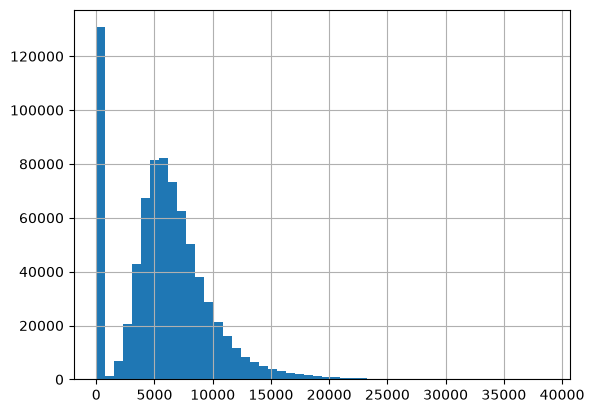

In [ ]:
df["Sales"].hist(bins=50)
plt.show()

As expected Sales is `right-skewed distributed` -> there are cases when store made 8 times more than usual.

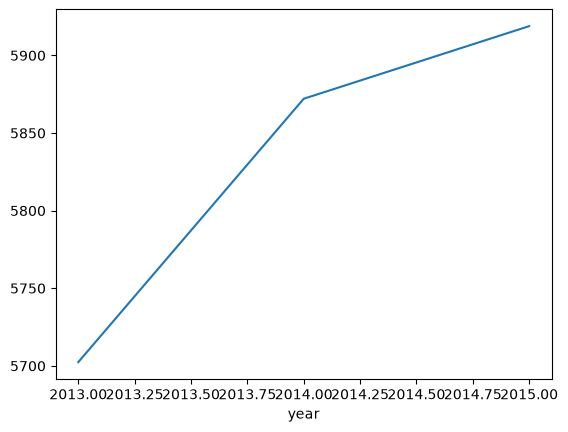

In [70]:
df.groupby("year")["Sales"].mean().plot()
plt.show()

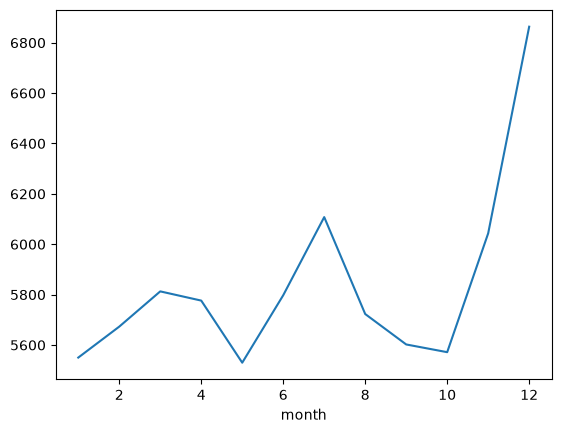

In [71]:
df.groupby("month")["Sales"].mean().plot()
plt.show()

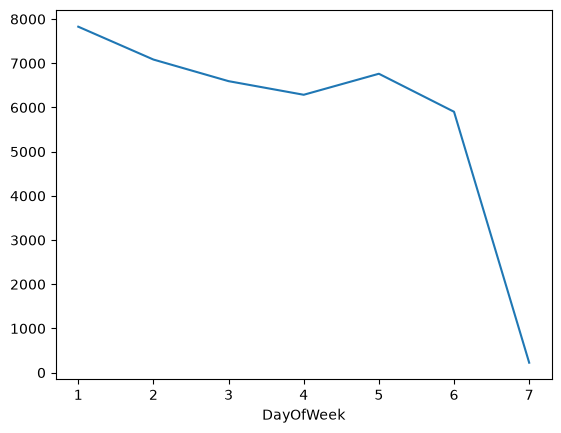

In [74]:
df.groupby("DayOfWeek")["Sales"].mean().plot()
plt.show()

Based on those plots i can tell that:
- Sales grew up for `4% from 2013 to 2015.`

- The spike of sales can be expected during `June-July and October-December periods`.

- `Mondays, Tuesdays, Wednesdays and Fridays` are especially popular amoung customers.

---